# Exercise 3: Multidimensional Data Filtering and Visualization

In [1]:
# Install necessary libraries so the notebook runs everywhere
%pip install pandas seaborn matplotlib scikit-learn numpy scipy

Note: you may need to restart the kernel to use updated packages.


### a) Read the dataset and print the first few rows
We need to load the dataset using the pandas library. If we look at the 'winequality-red.csv' file, we can see that the values are separated by a semicolon so we tell pandas to use " sep=';' " to read it correctly.

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('winequality-red.csv', sep=';')

# Print the first 5 rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### b) Display the distribution of quality scores and find the range
The 'quality' column has numerical scores. We can use seaborn to draw a histogram to see how these scores are distributed. To find the range, we just subtract the minimum score from the maximum score.

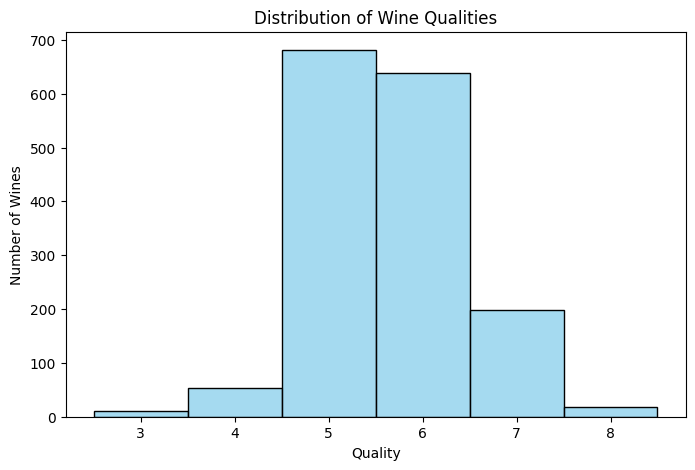

Minimum quality: 3
Maximum quality: 8
The range of the quality is 5


In [45]:
# Plot the histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['quality'], discrete=True, color='skyblue')
plt.title('Distribution of Wine Qualities')
plt.xlabel('Quality')
plt.ylabel('Number of Wines')
plt.show()

# Find the range
min_q = df['quality'].min()
max_q = df['quality'].max()
print(f"Minimum quality: {min_q}")
print(f"Maximum quality: {max_q}")
print(f"The range of the quality is {max_q - min_q}")

### c) Group quality into low, medium, and high bins
The scores in our dataset go from 3 to 8. 
- The two lowest scores are 3 and 4 -> 'low'
- The intermediate scores are 5 and 6 -> 'medium'
- The two highest scores are 7 and 8 -> 'high'

We will write a small function to group them and create a new column called 'quality bin' instead of 'quality'.

In [4]:
def group_quality(score):
    if score <= 4:
        return 'low'
    elif score <= 6:
        return 'medium'
    else:
        return 'high'

# Create the new column
df['quality bin'] = df['quality'].apply(group_quality)

# Drop the original 'quality' column
df = df.drop('quality', axis=1)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality bin
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,medium
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,medium
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,medium
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,medium


### d) Create a filtered data frame omitting medium-quality wines
We want to compare only the best and worst wines. So, we will filter our dataframe to remove all the rows where the quality is 'medium'.

In [ ]:
print(f"Total number of wines before filtering: {len(df)}")

# Fillter out 'medium' quality wines
df_filtered = df[df['quality bin'] != 'medium'].copy()

# Print how many wines we have left
print(f"Total number of wines after filtering: {len(df_filtered)}")
counts = df_filtered['quality bin'].value_counts()
print(f"High quality wines: {counts.get('high', 0)}")
print(f"Low quality wines: {counts.get('low', 0)}")


Total number of wines before filtering: 1599
Total number of wines after filtering: 280
High quality wines: 217
Low quality wines: 63


### e) Visualize all numerical attributes in a scatterplot matrix
We can use the pairplot function from seaborn. This function creates a huge matrix of scatterplots. We use the hue parameter to give different colors to 'low' and 'high' quality wines. 

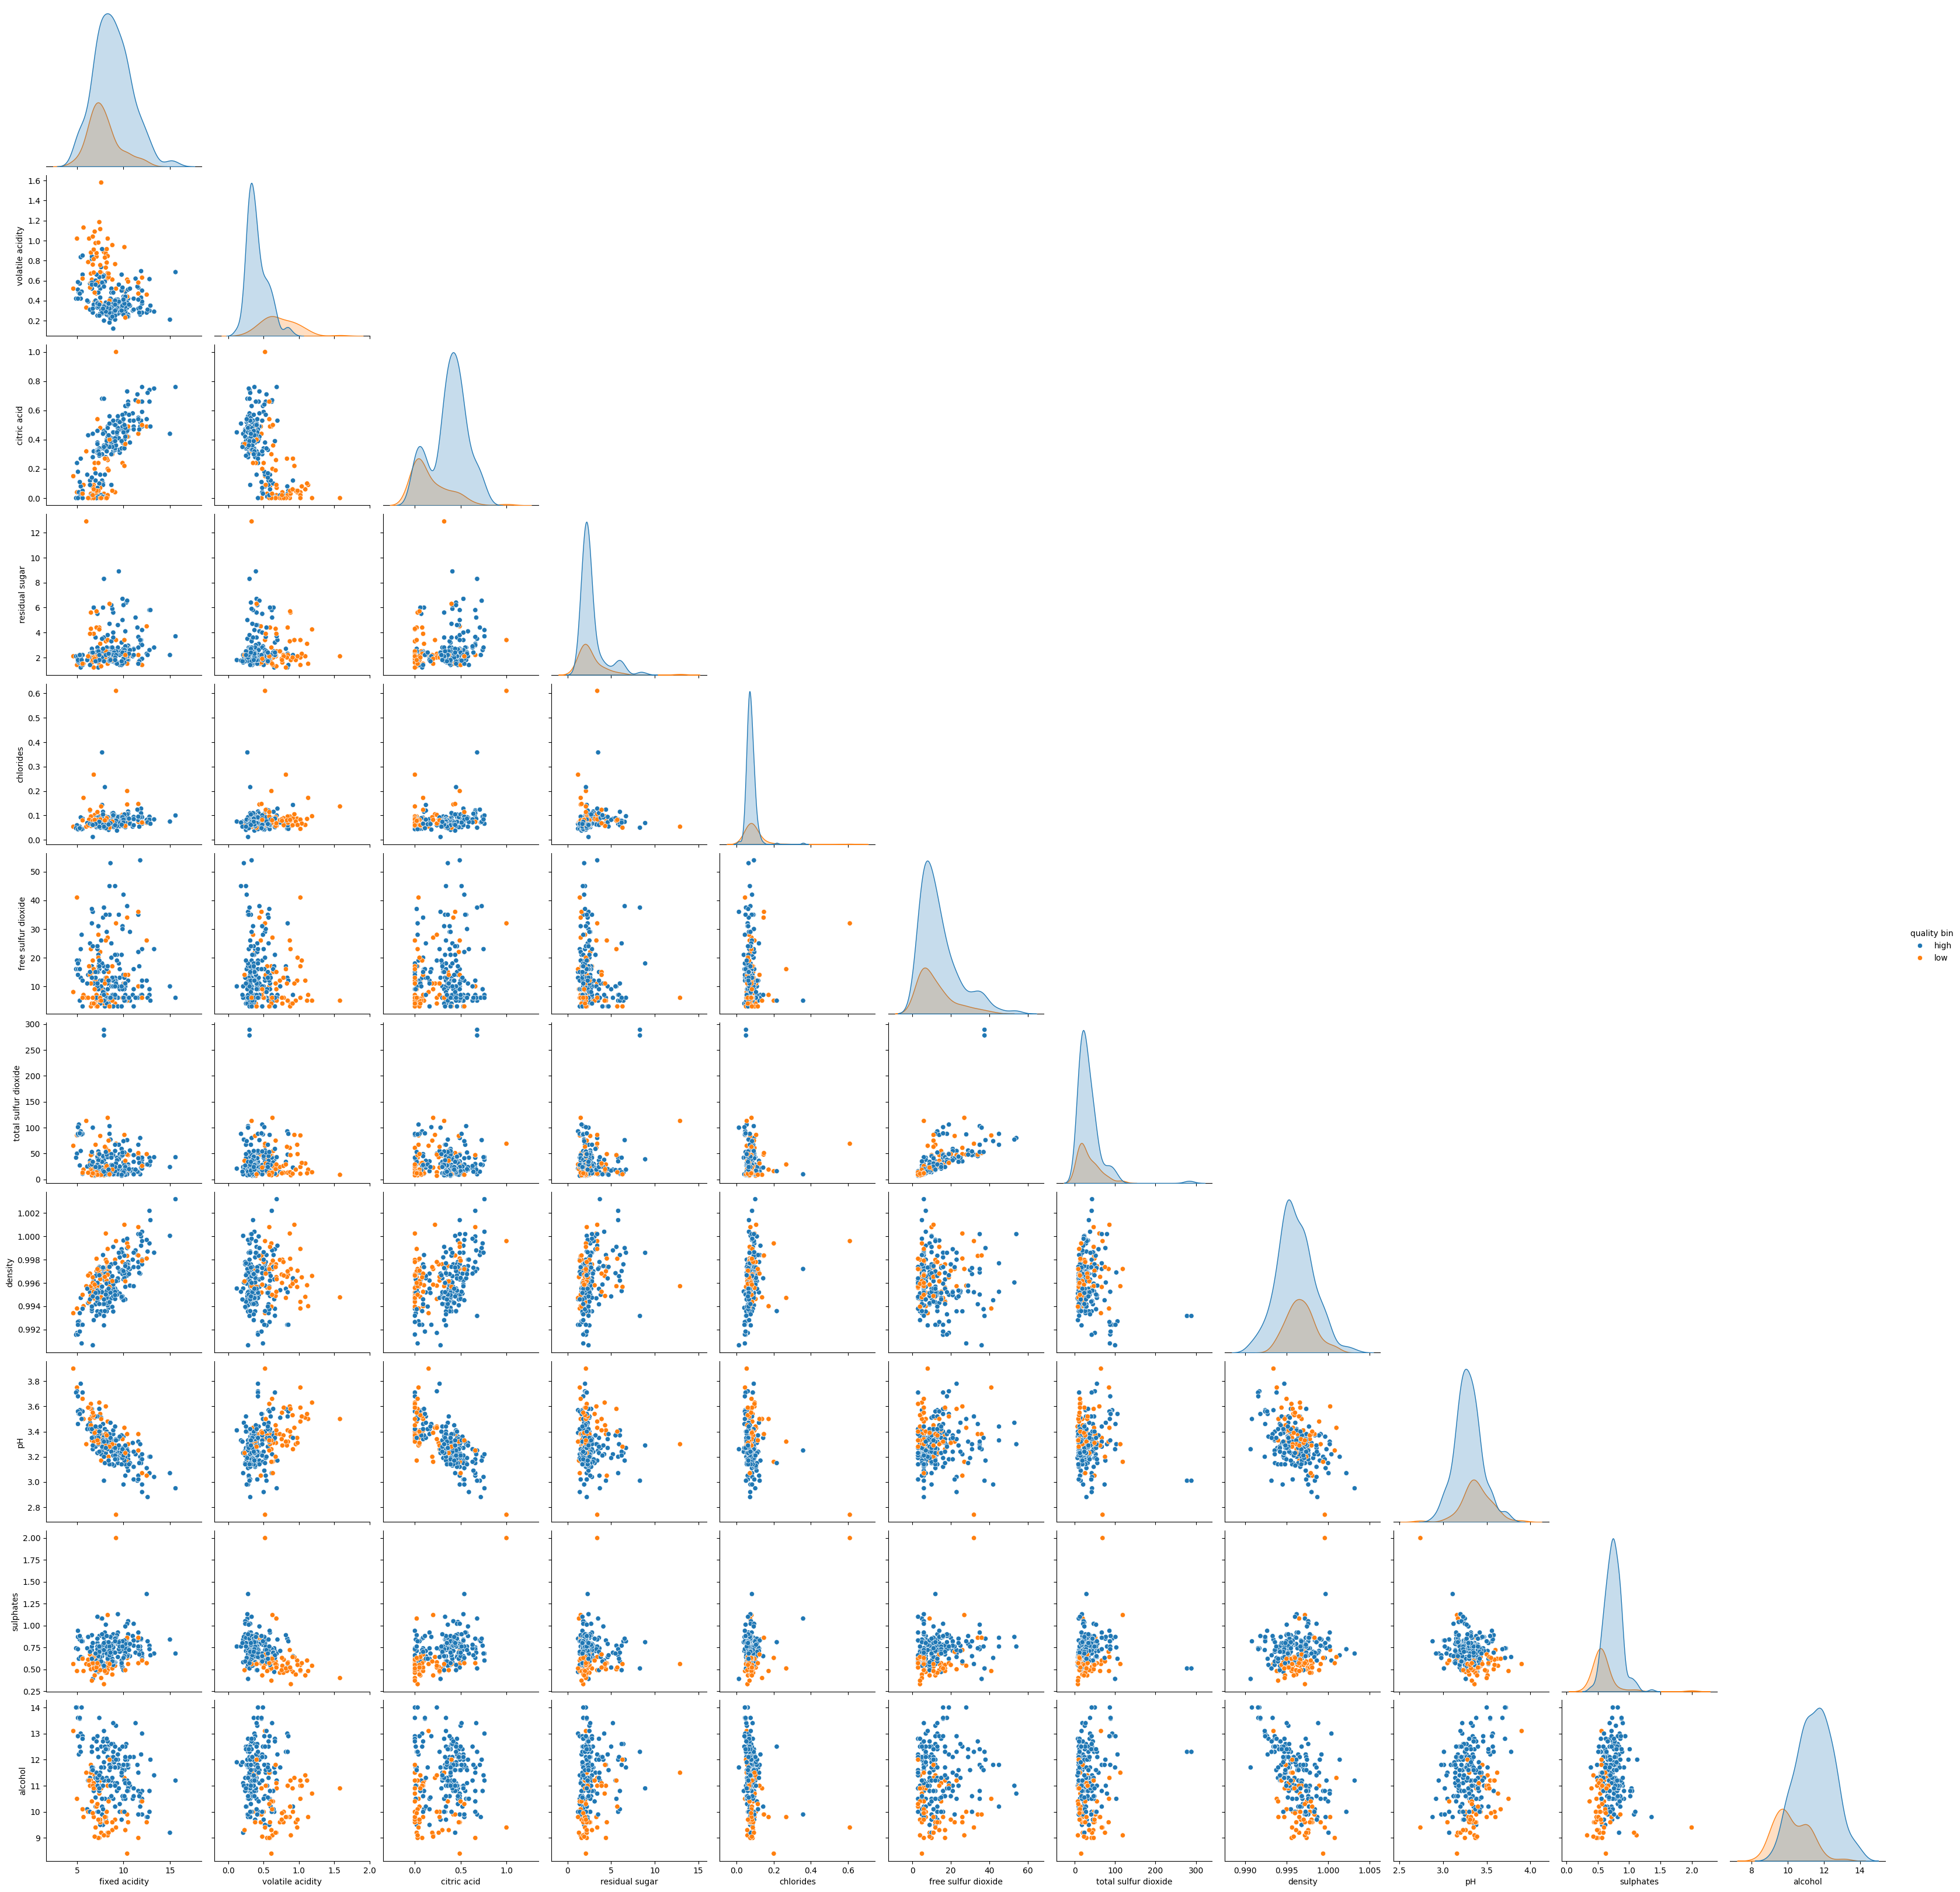

In [6]:
# Create scatterplot matrix
sns.pairplot(df_filtered, hue='quality bin', palette={'high': 'tab:blue', 'low': 'tab:orange'}, height=3, corner=True)
plt.show()

### f) Name five attributes that appear to best distinguish between high and low quality
By looking at the scatterplots above, we try to find the graphs where the blue dots (high) and orange dots (low) are clearly separated from each other. If they are mixed together, it is not a good attribute.

Based on visual inspection, the best 5 attributes is:
1. **alcohol**
2. **volatile acidity**
3. **citric acid**
4. **sulphates**
5. **fixed acidity**

### g) Use automated feature selection to identify the top five attributes
Instead of guessing with our eyes, we will use a mathematical method. We will use the F-score from ANOVA, which is available in scikit-learn as f_classif. We will select the top 5 features with the highest scores.

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

# Separate features (X) and target (y)
X = df_filtered.drop('quality bin', axis=1)
y = df_filtered['quality bin']

# Use SelectKBest to find the best 5 features using f_classif
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X, y)

# Create a dataframe to see the ranking clearly
scores_df = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': selector.scores_
})
scores_df = scores_df.sort_values(by='F_Score', ascending=False)

print("Ranking of all attributes:")
print(scores_df.to_string(index=False))

# Get the names of the top 5 features
top_5_features = scores_df['Feature'].head(5).tolist()

print("\nThe top 5 best attributes are:", top_5_features)

# Create the final filtered dataframe
columns_we_need = top_5_features + ['quality bin']
df_top5 = df_filtered[columns_we_need].copy().reset_index(drop=True)

df_top5.head()

Ranking of all attributes:
             Feature    F_Score
    volatile acidity 165.055077
             alcohol  86.049453
         citric acid  51.554562
           sulphates  44.345633
                  pH  17.481527
       fixed acidity  12.510219
           chlorides  10.152368
             density   4.828331
 free sulfur dioxide   1.800605
      residual sugar   0.013170
total sulfur dioxide   0.009867

The top 5 best attributes are: ['volatile acidity', 'alcohol', 'citric acid', 'sulphates', 'pH']


,volatile acidity,alcohol,citric acid,sulphates,pH,quality bin
0,0.65,10.0,0.00,0.47,3.39,high
1,0.58,9.5,0.02,0.57,3.36,high
2,0.28,10.5,0.56,0.75,3.30,high
3,0.59,9.0,0.08,0.50,3.38,low
4,0.38,9.7,0.28,0.73,3.23,high


**Are they the same as those you identified visually?**

They ar almost the same. We visually identified 4 out of 5 correctly (alcohol, volatile acidity, citric acid, and sulfates). However, for the fifth one, we guessed fixed acidity with our eyes, but the automated feature selection choose pH. 

**How does this automated method work?**

We used the ANOVA (Analysis of Variance) F-score. This statistical method calculates if the averages of our two groups ('high' and 'low' quality) are significantly different for a specific feature. If the difference between the two groups is large, it gives that feature a higher score. The SelectKBest algorithm then automatically picks the 5 features with the highest scores. This is why using a statistical method like ANOVA is more reliable and accurate than just visual inspection.

### h) Create a matrix similar to Fig. 1
Now we will create a special matrix only for our top 5 attributes. We will use seaborn's 'PairGrid'.
- On the diagonal: we will put density estimates.
- On the upper triangle: we will put scatterplots.
- On the lower triangle: we will put pairwise linear regression models.

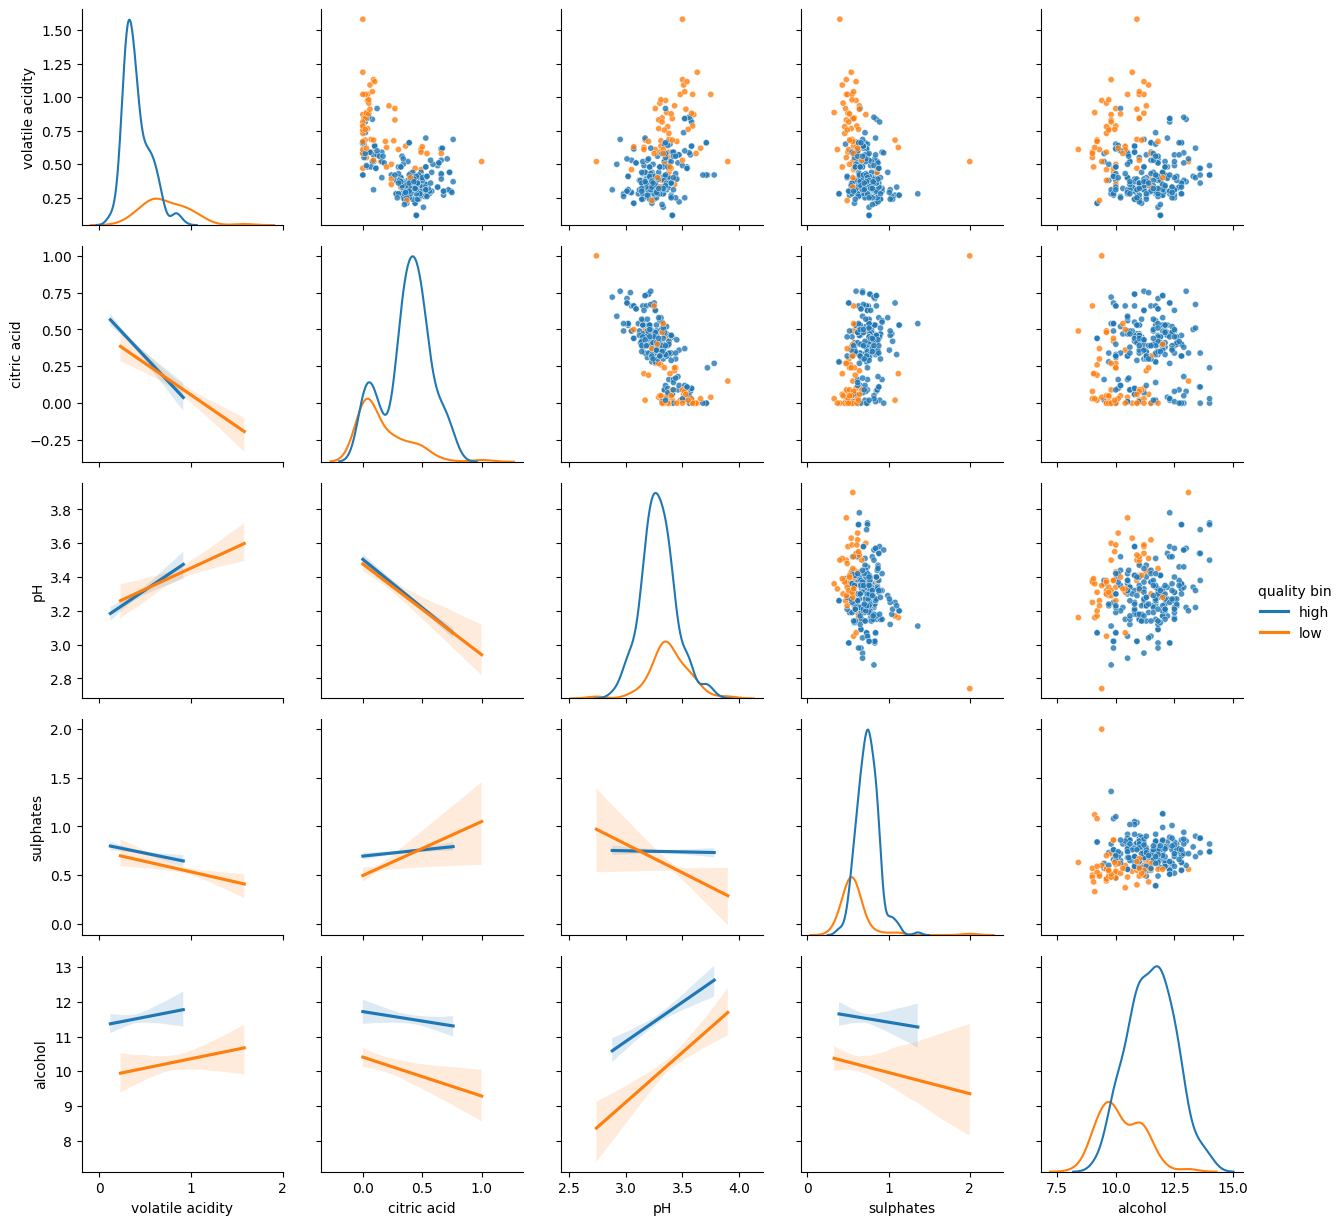

In [8]:
# To make sure that the positions of the features are same as in the assignment to compare our answers easily
df_top5 = df_top5[['volatile acidity', 'citric acid', 'pH', 'sulphates', 'alcohol', 'quality bin']]

# Initialize the PairGrid with our top 5 features dataframe
g = sns.PairGrid(df_top5, hue="quality bin", palette={'high': 'tab:blue', 'low': 'tab:orange'}, diag_sharey=False)

# Diagonal: Density estimates (kdeplot)
g.map_diag(sns.kdeplot, fill=False)

# Upper part: Scatterplots
g.map_upper(sns.scatterplot, s=20, alpha=0.8)

# Lower part: Linear regression models (regplot)
# We set scatter=False so it only draws the regression line and the confidence interval
g.map_lower(sns.regplot, scatter=False)

# Add a legend
g.add_legend()
plt.show()

**Note on the Density Plots (Diagonal):**

You might notice that our orange curves (low quality) are much shorter than the blue curves (high quality), whereas in the assignment's figure, they are about the same height. This happens because we have many more high-quality wines (217) than low-quality wines (63). By default, Seaborn makes the size of the curve proportional to the number of data points. 

If we want to ignore the counts and make both curves the same size (like in the assignment), we can add 'common_norm=False' to the 'kdeplot' function like this:
```python
g.map_diag(sns.kdeplot, fill=False, common_norm=False)
```

**1. Which attributes appear to be strongly correlated regardless of quality?**
Looking at the regression plots, we can identify four pairs with strong correlations for both quality classes:
- volatile acidity and citric acid: Negative correlation.
- pH and citric acid: Negative correlation.
- volatile acidity and pH: Positive correlation.
- pH and alcohol: Positive correlation.

**2. For which attributes does the amount of correlation appear to depend on the quality?**
We need to look for panels where the blue line and the orange line have very different slopes. Here are two clear examples:
- pH and sulphates: For high-quality wines, the line is completely flat (no corelation). But for low-quality wines, the line slopes downwards (negative correlation).
- citric acid and sulphates: For high-quality wines, the line is almost flat (no corelation). But for low-quality wines, the line slopes upward (positive correlation).

**3. Does any of the attributes appear to have a multimodal distribution?**
A multimodal distribution has more than one peak in the density plot. Looking at the diagonal plots, citric acid and sulfates have clear multimodal distributions. The curves goes up, goes down, and then goes up again, creating some distinct mountain peaks.

**4. Point out one or multiple data points that appear to be outliers.**
Outliers are dots that sit far away from the main cluster in the scatter plots. If you look at plots involving 'sulphates' (for example, sulphates vs pH), there is a single orange dot standing all alone at the right bottom. Such points are our outliers.

### j) Compute the distance consistency of all scatter plots
"Distance consistency" checks if data points of the same class (like 'high') are closer to each other than to data points of a different class (like 'low').

Since there is no ready-to-use function for this in Python packages, we will write our own algorithm. 
For every point in a scatter plot (a pair of variables):
1. We find its nearest neighbor (the closest point).
2. We check if they have the same label ('high' or 'low').
3. The consistency is the percentage of points that match their nearest neighbor's label.



In [41]:
from scipy.spatial.distance import cdist
import numpy as np

def get_distance_consistency(df, feature1, feature2, target_col):
    # Get the 2D coordinates for the scatterplot
    points = df[[feature1, feature2]].values
    labels = df[target_col].values
    
    # Calculate the distance between all pairs of points
    # This gives us a matrix of distances
    distances = cdist(points, points)
    
    # A point's distance to itself is 0. We must ignore it.
    # We make the diagonal very large (infinity) so it is never chosen as the minimum
    np.fill_diagonal(distances, np.inf)
    
    # Find the index of the closest point (nearest neighbor)
    nearest_indices = np.argmin(distances, axis=1)
    
    # Check if the label of the closest point is the same as the original point
    nearest_labels = labels[nearest_indices]
    is_consistent = (labels == nearest_labels)
    
    # The score is the average of matches (percentage)
    consistency_score = np.mean(is_consistent)
    return consistency_score

print("Distance consistency ranking:\n")

results = []

# Loop through all possible pairs of our top 5 features
for i in range(len(top_5_features)):
    for j in range(i + 1, len(top_5_features)):
        f1 = top_5_features[i]
        f2 = top_5_features[j]
        
        score = get_distance_consistency(df_top5, f1, f2, 'quality bin')
        results.append((score, f1, f2))

# Sort the results in descending order (highest score first)
results.sort(reverse=True)

# Print the ranked results as percentages
for rank, (score, f1, f2) in enumerate(results, 1):
    print(f"{rank}. {f1} & {f2} : {score*100:.2f}%")

best_score, best_f1, best_f2 = results[0]
print(f"\n=> The pair of variables that leads to the highest distance consistency is '{best_f1}' and '{best_f2}' with a score of {best_score*100:.2f}%.")


Distance consistency ranking:

1. volatile acidity & sulphates : 89.64%
2. alcohol & pH : 89.64%
3. volatile acidity & alcohol : 88.21%
4. sulphates & pH : 87.14%
5. volatile acidity & citric acid : 86.79%
6. alcohol & citric acid : 86.43%
7. alcohol & sulphates : 86.07%
8. volatile acidity & pH : 85.00%
9. citric acid & sulphates : 82.50%
10. citric acid & pH : 80.71%

=> The pair of variables that leads to the highest distance consistency is 'volatile acidity' and 'sulphates' with a score of 89.64%.


**What do these results mean?**

The distance consistency percentage tells us how well a specific pair of features groups the wines together in a 2D scatter plot. 

For example, a score of around 89% for alcohol and pH means that if we plot the wines using only these two attributes, 89% of the time a wine's closest neighbor will be a wine of the *exact same quality*. This shows that these two features combined create very distinct and tight clusters (a clear visual separation) between high-quality and low-quality wines. 

The ranking helps us immediately identify which 2D scatter plots in our matrix provide the most powerful visual classification.